 Global Superstore Data
Dataset: Global Superstore (Kaggle)  
The goal is to Clean the raw dataset so it is ready for analysis and dashboarding  

What This Notebook Does:
1. Load and inspect the raw data
2. Check for missing values
3. Fix data types
4. Remove duplicates
5. Clean column names
6. Handle outliers
7. Feature engineering (new useful columns)
8. Save the clean dataset

---

In [ ]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
#UPLOAD DATA
data = pd.read_csv("C:\\Users\\ÄGARE\\Desktop\\supperStore Data\\Supperstore\\Sample.csv", encoding='latin-1')
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52


Stage 3:- A general look at the data structure

In [5]:
# Column names and data types
print('=== COLUMN NAMES & DATA TYPES ===')
print(data.dtypes)

# Dataset shape and basic info
print('=== DATASET INFO ===')
data.info()

# Statistical summary of numeric columns
print('=== STATISTICAL SUMMARY ===')
data.describe()

=== COLUMN NAMES & DATA TYPES ===
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
=== DATASET INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [6]:
# Clean column names:
# - Lowercase everything
# - Replace spaces with underscores
# - Remove special characters

data.columns = (
    data.columns
    .str.strip()           # remove leading/trailing spaces
    .str.lower()           # make lowercase
    .str.replace(' ', '_') # spaces to underscores
    .str.replace('-', '_') # hyphens to underscores
    .str.replace('/', '_') # slashes to underscores
    .str.replace('(', '')  # remove brackets
    .str.replace(')', '')  # remove brackets
)

print('=== CLEANED COLUMN NAMES ===')
print(data.columns.tolist())
print(f'\n✅ Column names cleaned')

=== CLEANED COLUMN NAMES ===
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']

✅ Column names cleaned


In [7]:
# Count missing values per column
missing = data.isnull().sum()
missing_pct = (data.isnull().sum() / len(data) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print('=== MISSING VALUES REPORT ===')
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print('✅ No missing values found!')
else:
    print(f'\n⚠️  Total missing values: {missing_df["Missing Count"].sum():,}')

=== MISSING VALUES REPORT ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
✅ No missing values found!


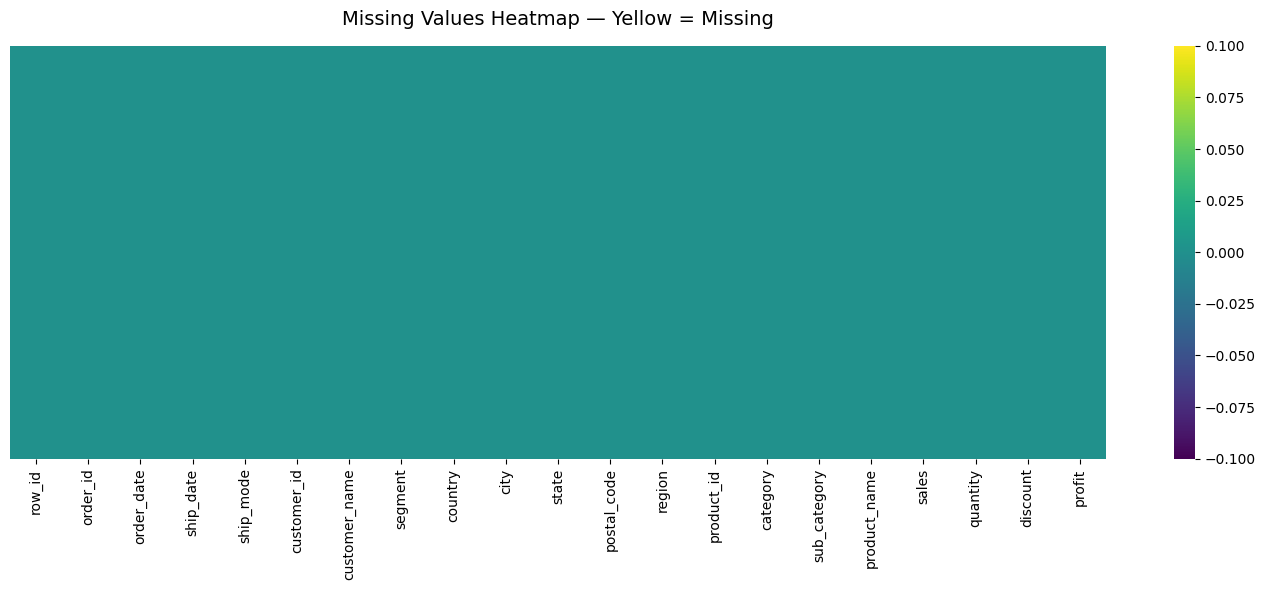

✅ Heatmap saved as missing_values_heatmap.png


In [8]:
# Visualise missing values as a heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(
    data.isnull(),
    yticklabels=False,
    cbar=True,
    cmap='viridis'
)
plt.title('Missing Values Heatmap — Yellow = Missing', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('missing_values_heatmap.png', dpi=150)
plt.show()
print('✅ Heatmap saved as missing_values_heatmap.png')

In [9]:
# Handle missing values
# -------------------------------------------------------
# Having missing values in Global Superstore postal_code' column often Common in retail datasets due to data entry issues or incomplete customer information.
# We fill with 'UNKNOWN' since it is not critical for analysis

if 'postal_code' in data.columns:
    missing_postal = data['postal_code'].isnull().sum()
    data['postal_code'] = data['postal_code'].fillna('UNKNOWN')
    print(f'✅ postal_code: filled {missing_postal:,} missing values with UNKNOWN')

# For any other text columns with small amounts of missing values
text_cols = data.select_dtypes(include='object').columns
for col in text_cols:
    missing_count = data[col].isnull().sum()
    if missing_count > 0:
        data[col] = data[col].fillna('UNKNOWN')
        print(f'✅ {col}: filled {missing_count:,} missing values with UNKNOWN')

# For numeric columns — fill with median (safer than mean for skewed data)
num_cols = data.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    missing_count = data[col].isnull().sum()
    if missing_count > 0:
        median_val = data[col].median()
        data[col] = data[col].fillna(median_val)
        print(f'✅ {col}: filled {missing_count:,} missing values with median ({median_val:.2f})')

# Confirm no missing values remain
remaining = data.isnull().sum().sum()
print(f'\n✅ Total missing values remaining: {remaining}')

✅ postal_code: filled 0 missing values with UNKNOWN

✅ Total missing values remaining: 0


In [11]:
# Convert date columns to datetime
date_columns = ['order_date', 'ship_date']

for col in date_columns:
    if col in data.columns:
        data[col] = pd.to_datetime(data[col])
        print(f'✅ {col} converted to datetime — sample: {data[col].iloc[0]}')
print()

# Convert numeric columns that may be stored as strings
numeric_columns = ['sales', 'quantity', 'discount', 'profit', 'shipping_cost']

for col in numeric_columns:
    if col in data.columns:
        # Remove any currency symbols or commas if present
        if data[col].dtype == 'object':
            data[col] = data[col].str.replace(',', '').str.replace('$', '').str.strip()
        data[col] = pd.to_numeric(data[col], errors='coerce')
        print(f'✅ {col} converted to numeric — dtype: {data[col].dtype}')

print('\n=== UPDATED DATA TYPES ===')
print(data.dtypes)

✅ order_date converted to datetime — sample: 2016-11-08 00:00:00
✅ ship_date converted to datetime — sample: 2016-11-11 00:00:00

✅ sales converted to numeric — dtype: float64
✅ quantity converted to numeric — dtype: int64
✅ discount converted to numeric — dtype: float64
✅ profit converted to numeric — dtype: float64

=== UPDATED DATA TYPES ===
row_id                    int64
order_id                    str
order_date       datetime64[us]
ship_date        datetime64[us]
ship_mode                   str
customer_id                 str
customer_name               str
segment                     str
country                     str
city                        str
state                       str
postal_code               int64
region                      str
product_id                  str
category                    str
sub_category                str
product_name                str
sales                   float64
quantity                  int64
discount                float64
profit       

Checking for duplicates and removing them

In [ ]:
# Check for duplicate rows
total_duplicates = data.duplicated().sum()
print(f'=== DUPLICATE CHECK ===')
print(f'Total duplicate rows found: {total_duplicates:,}')

# Show duplicated rows if any
if total_duplicates > 0:
    

# Remove duplicate rows
rows_before = len(data)
data = data.drop_duplicates()
rows_after = len(data)
removed = rows_before - rows_after 

=== DUPLICATE CHECK ===
Total duplicate rows found: 0
Rows before: 9,994
Rows after : 9,994
Removed    : 0 duplicate rows

✅ Duplicate removal complete


Clean Text Columns
Remove extra whitespace, fix inconsistent capitalisation.

In [ ]:
# Clean all text/object columns
text_columns = data.select_dtypes(include='object').columns

for col in text_columns:
    # Remove leading and trailing whitespace
    data[col] = data[col].str.strip()
    # Fix multiple spaces inside values
    data[col] = data[col].str.replace(r'\s+', ' ', regex=True)


# Check unique values in key categorical columns
categorical_cols = ['segment', 'category', 'sub_category', 'ship_mode', 'region', 'market']

for col in categorical_cols:
    if col in data.columns:
        unique_vals = data[col].unique()

# Fix any inconsistent capitalisation in categories
# Example: 'technology' and 'Technology' should be the same

for col in categorical_cols:
    if col in data.columns:
        data[col] = data[col].str.title()  # Title Case: first letter uppercase


✅ Whitespace cleaned in 13 text columns
   Columns cleaned: ['order_id', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'region', 'product_id', 'category', 'sub_category', 'product_name']

SEGMENT (3 unique values):
['Consumer', 'Corporate', 'Home Office']

CATEGORY (3 unique values):
['Furniture', 'Office Supplies', 'Technology']

SUB_CATEGORY (17 unique values):
['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables']

SHIP_MODE (4 unique values):
['First Class', 'Same Day', 'Second Class', 'Standard Class']

REGION (4 unique values):
['Central', 'East', 'South', 'West']
✅ Categorical columns standardised to Title Case


Checking for Nagative Values and removing them. Sales and Quantity Should never be nagative

In [ ]:
# Check for negative sales
if 'sales' in data.columns:
    neg_sales = data[data['sales'] < 0]
    print(f'Negative sales values: {len(neg_sales):,}')
    if len(neg_sales) > 0:
        print(neg_sales[['order_id', 'sales', 'profit']].head())

# Check for negative quantity
if 'quantity' in data.columns:
    neg_qty = data[data['quantity'] < 0]
    print(f'\nNegative quantity values: {len(neg_qty):,}')
    if len(neg_qty) > 0:
        print(neg_qty[['order_id', 'quantity']].head())

# Profit negative is normal (means a loss on that order — keep it)
if 'profit' in data.columns:
    neg_profit = data[data['profit'] < 0]
    print(f'\nNegative profit (loss) rows: {len(neg_profit):,}')
    print('  Note: Negative profit = loss on order. This is NORMAL — do not remove.')

# Remove rows where sales or quantity is negative or zero
# (these are data entry errors)

rows_before = len(data)

if 'sales' in data.columns:
    data = data[data['sales'] > 0]

if 'quantity' in data.columns:
    data = data[data['quantity'] > 0]

rows_after = len(data)
print(f'Rows before cleaning: {rows_before:,}')
print(f'Rows after cleaning : {rows_after:,}')
print(f'Rows removed        : {rows_before - rows_after:,}')
print('\n✅ Invalid sales and quantity rows removed')    

Using IQR Method to dictect and handle extrem outliers in Sales and Profits 

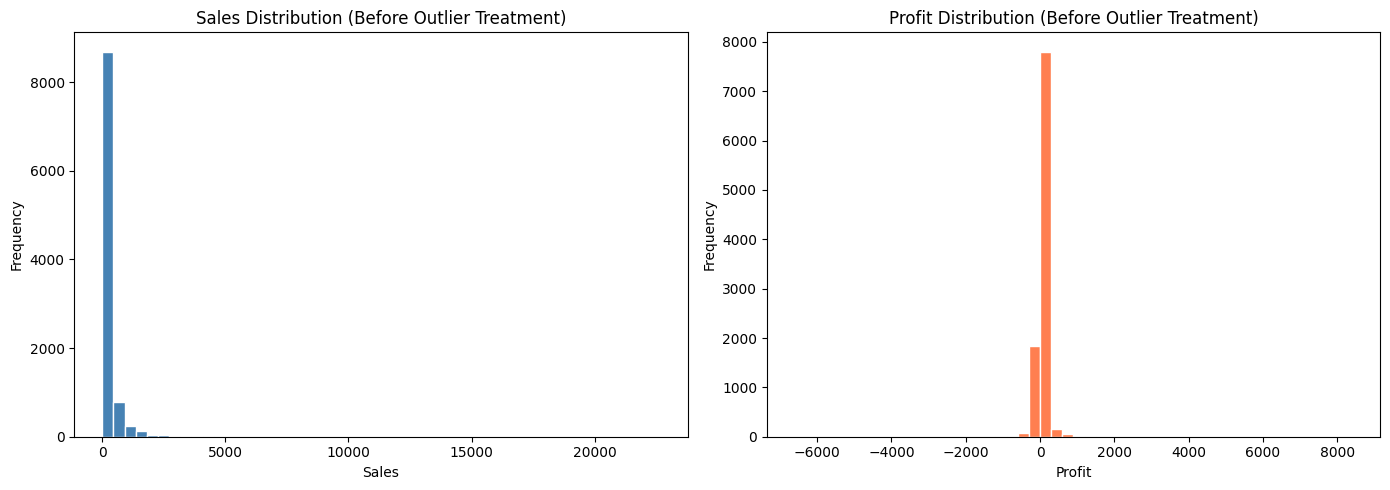

✅ Distribution charts saved


In [14]:
# Visualise distribution of Sales before outlier treatment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales distribution
if 'sales' in data.columns:
    axes[0].hist(data['sales'], bins=50, color='steelblue', edgecolor='white')
    axes[0].set_title('Sales Distribution (Before Outlier Treatment)', fontsize=12)
    axes[0].set_xlabel('Sales')
    axes[0].set_ylabel('Frequency')

# Profit distribution
if 'profit' in data.columns:
    axes[1].hist(data['profit'], bins=50, color='coral', edgecolor='white')
    axes[1].set_title('Profit Distribution (Before Outlier Treatment)', fontsize=12)
    axes[1].set_xlabel('Profit')
    axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distributions_before.png', dpi=150)
plt.show()
print('✅ Distribution charts saved')

In [15]:
# IQR Outlier Detection — Flag outliers, do NOT remove them
# In business data, high sales values are real — we flag but keep them

def flag_outliers(dataframe, column):
    """Flag outliers using the IQR method."""
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_flag = (dataframe[column] < lower) | (dataframe[column] > upper)
    return outlier_flag, lower, upper

# Flag sales outliers
if 'sales' in data.columns:
    flag, low, high = flag_outliers(data, 'sales')
    data['sales_outlier_flag'] = flag
    n = flag.sum()
    print(f'Sales outliers flagged : {n:,} rows ({n/len(data)*100:.1f}%)')
    print(f'  Normal range         : {low:.2f} to {high:.2f}')

# Flag profit outliers
if 'profit' in data.columns:
    flag, low, high = flag_outliers(data, 'profit')
    data['profit_outlier_flag'] = flag
    n = flag.sum()
    print(f'\nProfit outliers flagged: {n:,} rows ({n/len(data)*100:.1f}%)')
    print(f'  Normal range         : {low:.2f} to {high:.2f}')

print('\n✅ Outliers flagged (not removed — flagged for analysis awareness)')

Sales outliers flagged : 1,167 rows (11.7%)
  Normal range         : -271.71 to 498.93

Profit outliers flagged: 1,881 rows (18.8%)
  Normal range         : -39.72 to 70.82

✅ Outliers flagged (not removed — flagged for analysis awareness)


Creating New Columns That will be usefull for Analysis and Dashboarding 

In [ ]:
# ── Date-based features ──────────────────────────────────
if 'order_date' in data.columns:
    data['order_year']    = data['order_date'].dt.year
    data['order_month']   = data['order_date'].dt.month
    data['order_month_name'] = data['order_date'].dt.month_name()
    data['order_quarter'] = data['order_date'].dt.quarter
    data['order_quarter_label'] = 'Q' + data['order_quarter'].astype(str)
    data['order_day_of_week'] = data['order_date'].dt.day_name()
    data['order_week']    = data['order_date'].dt.isocalendar().week.astype(int)
    

# ── Shipping days (how long did shipping take?) ──────────
if 'order_date' in data.columns and 'ship_date' in data.columns:
    data['shipping_days'] = (data['ship_date'] - data['order_date']).dt.days
    # Flag any shipping days that are negative (data error)
    neg_ship = data[data['shipping_days'] < 0]
    if len(neg_ship) > 0:
        print(f'⚠️  {len(neg_ship)} rows have negative shipping days — investigate!')
        data = data[data['shipping_days'] >= 0]  # remove negative shipping days


# ── Profit margin ────────────────────────────────────────
if 'profit' in data.columns and 'sales' in data.columns:
    data['profit_margin_pct'] = (data['profit'] / data['sales'] * 100).round(2)

# ── Revenue per unit ─────────────────────────────────────
if 'sales' in data.columns and 'quantity' in data.columns:
    data['revenue_per_unit'] = (data['sales'] / data['quantity']).round(2)

# ── Discount flag ─────────────────────────────────────────
if 'discount' in data.columns:
    data['is_discounted'] = data['discount'] > 0
    pct_discounted = data['is_discounted'].mean() * 100

# ── Profit category ───────────────────────────────────────
if 'profit' in data.columns:
    data['profit_category'] = pd.cut(
        data['profit'],
        bins=[-np.inf, 0, 100, 500, np.inf],
        labels=['Loss', 'Low Profit', 'Medium Profit', 'High Profit']
    )


✅ Date features created: year, month, quarter, day_of_week, week
✅ shipping_days created — average: 4.0 days
✅ profit_margin_pct created — average: 12.0%
✅ revenue_per_unit created
✅ is_discounted flag created — 52.0% of orders were discounted
✅ profit_category created: Loss / Low / Medium / High Profit

✅ All feature engineering complete


In [19]:
# Final look at the clean dataset
print('=== FINAL COLUMN LIST ===')
for i, col in enumerate(data.columns, 1):
    print(f'  {i:02d}. {col} ({data[col].dtype})')

=== FINAL COLUMN LIST ===
  01. row_id (int64)
  02. order_id (str)
  03. order_date (datetime64[us])
  04. ship_date (datetime64[us])
  05. ship_mode (str)
  06. customer_id (str)
  07. customer_name (str)
  08. segment (str)
  09. country (str)
  10. city (str)
  11. state (str)
  12. postal_code (int64)
  13. region (str)
  14. product_id (str)
  15. category (str)
  16. sub_category (str)
  17. product_name (str)
  18. sales (float64)
  19. quantity (int64)
  20. discount (float64)
  21. profit (float64)
  22. sales_outlier_flag (bool)
  23. profit_outlier_flag (bool)
  24. order_year (int32)
  25. order_month (int32)
  26. order_month_name (str)
  27. order_quarter (int32)
  28. order_quarter_label (str)
  29. order_day_of_week (str)
  30. order_week (int64)
  31. shipping_days (int64)
  32. profit_margin_pct (float64)
  33. revenue_per_unit (float64)
  34. is_discounted (bool)
  35. profit_category (category)


In [21]:
# Preview the clean dataset
print('=== CLEAN DATASET PREVIEW ===')
data.head(5)

=== CLEAN DATASET PREVIEW ===


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,sales_outlier_flag,profit_outlier_flag,order_year,order_month,order_month_name,order_quarter,order_quarter_label,order_day_of_week,order_week,shipping_days,profit_margin_pct,revenue_per_unit,is_discounted,profit_category
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,False,False,2016,11,November,4,Q4,Tuesday,45,3,16.00,130.98,False,Low Profit
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,True,True,2016,11,November,4,Q4,Tuesday,45,3,30.00,243.98,False,Medium Profit
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,False,False,2016,6,June,2,Q2,Sunday,23,4,47.00,7.31,False,Low Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,True,True,2015,10,October,4,Q4,Sunday,41,7,-40.00,191.52,True,Loss
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,False,False,2015,10,October,4,Q4,Sunday,41,7,11.25,11.18,True,Low Profit


In [ ]:
# Save as CSV — use this for Power BI and further analysis
data.to_csv('Global_Superstore_CLEAN.csv', index=False)

✅ Clean dataset saved as: Global_Superstore_CLEAN.csv
